In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.ssl_joint import DualPretextSSLModel
from src.ssl_contrastive import GridDataAugmenter, NTXentLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 10 Joint Pretraining on: {device}")

# 1. Ingest LCL pretraining windows (Phase 4 artifact)
lcl_path = Path('../data/ssl_pretraining/lcl_windows.npz')
npz_data = np.load(lcl_path)

X_train_lcl = npz_data['X_train']  # (12217, 48, 25)
X_val_lcl   = npz_data['X_val']    # (2581, 48, 25)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_lcl)),
    batch_size=128,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_lcl)),
    batch_size=128,
    shuffle=False,
    drop_last=True
)

# 2. Instantiate Model, Augmenter, and Objectives
augmenter = GridDataAugmenter(jitter_sigma=0.015, scale_range=(0.90, 1.10), mask_block_len=4)
model = DualPretextSSLModel(
    in_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    proj_dim=64,
    mask_ratio=0.20
).to(device)

criterion_rec = torch.nn.MSELoss()
criterion_con = NTXentLoss(temperature=0.1)

# Balancing weights: λ_rec and λ_con
lambda_rec = 10.0   # Scale MSE (~0.005) into ~0.05 range
lambda_con = 1.0    # NT-Xent is naturally on ~0.1 - 2.0 scale

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

print("Dual Pretext SSL Model initialized successfully on CUDA.")

Executing Phase 10 Joint Pretraining on: cuda
Dual Pretext SSL Model initialized successfully on CUDA.


In [2]:
EPOCHS = 20
best_val_loss = float('inf')
history = {
    'total_train': [], 'rec_train': [], 'con_train': [],
    'total_val': [],   'rec_val': [],   'con_val': []
}

print(f"--- Starting Joint Pretraining: L_SSL = {lambda_rec} * L_rec + {lambda_con} * L_con ({EPOCHS} Epochs) ---")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_total, running_rec, running_con = 0.0, 0.0, 0.0
    
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        
        # --- Task 1: Masked Temporal Reconstruction ---
        x_rec, _ = model.forward_reconstruction(x_batch)
        loss_rec = criterion_rec(x_rec, x_batch)
        
        # --- Task 2: Contrastive Invariance ---
        view_A = augmenter.generate_augmented_view(x_batch)
        view_B = augmenter.generate_augmented_view(x_batch)
        z_A = model.forward_contrastive(view_A)
        z_B = model.forward_contrastive(view_B)
        loss_con = criterion_con(z_A, z_B)
        
        # Joint Multi-Task Loss
        total_loss = (lambda_rec * loss_rec) + (lambda_con * loss_con)
        total_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        running_total += total_loss.item()
        running_rec += loss_rec.item()
        running_con += loss_con.item()
        
    train_total = running_total / len(train_loader)
    train_rec   = running_rec / len(train_loader)
    train_con   = running_con / len(train_loader)
    scheduler.step()
    
    # --- Validation Evaluation ---
    model.eval()
    val_total, val_rec, val_con = 0.0, 0.0, 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            
            # Rec val
            x_rec, _ = model.forward_reconstruction(x_batch)
            l_rec = criterion_rec(x_rec, x_batch)
            
            # Con val
            v_A = augmenter.generate_augmented_view(x_batch)
            v_B = augmenter.generate_augmented_view(x_batch)
            zA = model.forward_contrastive(v_A)
            zB = model.forward_contrastive(v_B)
            l_con = criterion_con(zA, zB)
            
            t_loss = (lambda_rec * l_rec) + (lambda_con * l_con)
            val_total += t_loss.item()
            val_rec   += l_rec.item()
            val_con   += l_con.item()
            
    val_total = val_total / len(val_loader)
    val_rec   = val_rec / len(val_loader)
    val_con   = val_con / len(val_loader)
    
    history['total_train'].append(train_total)
    history['rec_train'].append(train_rec)
    history['con_train'].append(train_con)
    history['total_val'].append(val_total)
    history['rec_val'].append(val_rec)
    history['con_val'].append(val_con)
    
    # Save the main research model checkpoint (backbone only)
    if val_total < best_val_loss:
        best_val_loss = val_total
        save_dir = Path('../saved_models')
        save_dir.mkdir(parents=True, exist_ok=True)
        # Full joint model
        torch.save(model.state_dict(), save_dir / 'ssl_joint_dual_pretext_full.pth')
        # Crucial: Pretrained CNN + BiLSTM Backbone for Downstream Fine-Tuning
        torch.save(model.encoder.state_dict(), save_dir / 'ssl_joint_pretrained_encoder.pth')

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | "
              f"Total Loss: {train_total:.4f} (Val: {val_total:.4f}) | "
              f"Rec MSE: {train_rec:.6f} | Con NT-Xent: {train_con:.4f}")

print(f"\n[SUCCESS] Joint Dual-Pretext Pretraining Completed. Best Val Loss: {best_val_loss:.4f}")
print("Main Research Model Weights saved to: ../saved_models/ssl_joint_pretrained_encoder.pth")

--- Starting Joint Pretraining: L_SSL = 10.0 * L_rec + 1.0 * L_con (20 Epochs) ---
Epoch [01/20] | Total Loss: 0.7629 (Val: 3.1457) | Rec MSE: 0.033637 | Con NT-Xent: 0.4265
Epoch [02/20] | Total Loss: 0.2767 (Val: 2.5727) | Rec MSE: 0.010299 | Con NT-Xent: 0.1737
Epoch [04/20] | Total Loss: 0.1913 (Val: 2.2291) | Rec MSE: 0.007695 | Con NT-Xent: 0.1144
Epoch [06/20] | Total Loss: 0.1649 (Val: 2.0550) | Rec MSE: 0.006832 | Con NT-Xent: 0.0966
Epoch [08/20] | Total Loss: 0.1458 (Val: 1.8384) | Rec MSE: 0.006117 | Con NT-Xent: 0.0847
Epoch [10/20] | Total Loss: 0.1402 (Val: 1.8007) | Rec MSE: 0.005470 | Con NT-Xent: 0.0855
Epoch [12/20] | Total Loss: 0.1246 (Val: 1.6776) | Rec MSE: 0.004983 | Con NT-Xent: 0.0748
Epoch [14/20] | Total Loss: 0.1156 (Val: 1.5894) | Rec MSE: 0.004611 | Con NT-Xent: 0.0695
Epoch [16/20] | Total Loss: 0.1126 (Val: 1.5856) | Rec MSE: 0.004413 | Con NT-Xent: 0.0685
Epoch [18/20] | Total Loss: 0.1081 (Val: 1.5473) | Rec MSE: 0.004310 | Con NT-Xent: 0.0650
Epoch [

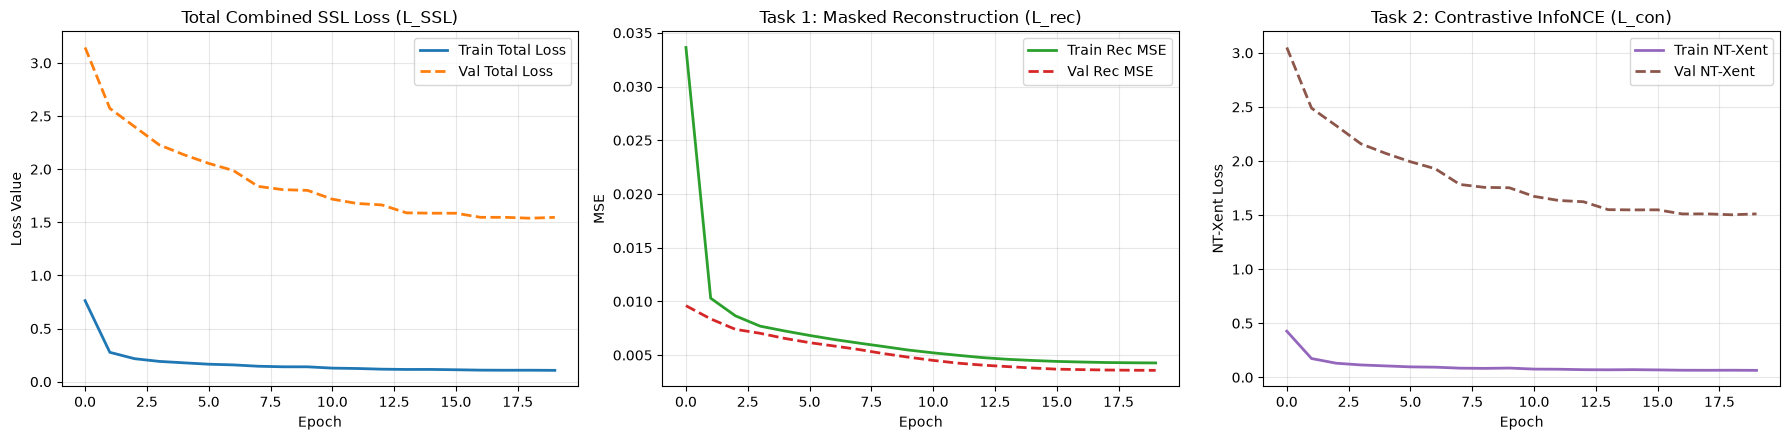

In [3]:
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# 1. Total Joint SSL Loss
axes[0].plot(history['total_train'], label='Train Total Loss', color='#1f77b4', lw=2)
axes[0].plot(history['total_val'], label='Val Total Loss', color='#ff7f0e', lw=2, linestyle='--')
axes[0].set_title('Total Combined SSL Loss (L_SSL)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Reconstruction Branch (MSE)
axes[1].plot(history['rec_train'], label='Train Rec MSE', color='#2ca02c', lw=2)
axes[1].plot(history['rec_val'], label='Val Rec MSE', color='#d62728', lw=2, linestyle='--')
axes[1].set_title('Task 1: Masked Reconstruction (L_rec)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Contrastive Branch (NT-Xent)
axes[2].plot(history['con_train'], label='Train NT-Xent', color='#9467bd', lw=2)
axes[2].plot(history['con_val'], label='Val NT-Xent', color='#8c564b', lw=2, linestyle='--')
axes[2].set_title('Task 2: Contrastive InfoNCE (L_con)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('NT-Xent Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'ssl_joint_pretraining_losses.png', dpi=300)
plt.show()